# FraudShield AI: Payment Fraud Sequence Detection using LSTM/RNN

**Course:** Deep Learning &nbsp;|&nbsp; **Program:** MAIB Sept 25 — Term 3

**Group:** Krishna Mathur · Yash Petkar · Atharva Soundankar · __________

---
## 1. Objective

Detect payment fraud from a customer's **sequence of transactions** using deep learning, and map each
transaction to a **fraud probability** + **business action** (Approve / Review / Block).

**What's deep-learning-correct here:**
- **Masked, variable-length sequences** (many-to-one): score the *current* transaction using up to N
  preceding transactions of the same account. Works on the REAL PaySim data, where most accounts have
  very few transactions (a per-customer fixed-window model would collapse).
- A **toolkit matched to the use-case**: Dense baseline, **LSTM** (hero), GRU, **1D-CNN**, and an
  **Autoencoder** anomaly detector for novel fraud.
- **Focal loss + class weights** for the extreme imbalance, and **PR-AUC / recall** as the headline
  metrics (not accuracy).

> **Framework note:** we use **PyTorch** (TensorFlow segfaults on Apple-Silicon / Python 3.13 / NumPy 2).
> The architectures are identical; only the framework differs.


## 2. Business Problem
Fraud hides in behaviour over time: a normal account suddenly makes a large transfer that drains the
balance to zero, the destination (mule) balance never updates, then a rapid cash-out. A single-row rule
can't see this story; a sequence model can.


## 3. Imports


In [1]:
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Make the project root importable so we reuse the tested src/ modules.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src import config
from src import dl_models as dl
from src import evaluate_model as ev
from src.data_loader import load_data, basic_overview
from src.feature_engineering import engineer_features
from src.preprocessing import clean_data, fit_scaler, save_scaler
from src.sequence_builder import build_padded_sequences, stratified_split
from src.utils import set_seeds
import torch
set_seeds(config.RANDOM_SEED)
print('PyTorch', torch.__version__, '| features:', len(config.FEATURE_COLUMNS),
      '| sequence length:', config.SEQUENCE_LENGTH)

PyTorch 2.11.0 | features: 14 | sequence length: 10


> **First time?** Run `pip install -r requirements.txt` (PyTorch, scikit-learn, …) and
> `python src/make_sample_data.py` from the project root.


## 4. Load Data
Prefers `data/paysim.csv`; falls back to the synthetic sample so the notebook always runs.


In [2]:
df, source = load_data()
print('Data source:', source)
if source != 'real':
    print('WARNING: SAMPLE data (demo only). Add data/paysim.csv for real results.')
df.head()

[FraudShield] Real dataset not found. Loading SAMPLE (demo only): /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/data/sample_transactions.csv
Data source: sample


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,5854.22,C1000000,68970.64,63116.42,M1438878,0.00,0.00,0,0
1,2,CASH_IN,6299.21,C1000000,63116.42,69415.63,C8839747,2562.27,0.00,0,0
2,3,TRANSFER,5562.05,C1000000,69415.63,63853.58,C8450385,12877.30,18439.35,0,0
3,4,CASH_IN,3575.14,C1000000,63853.58,67428.72,C8092135,4544.77,969.63,0,0
4,5,PAYMENT,4969.23,C1000000,67428.72,62459.49,M1554584,0.00,0.00,0,0


## 5. Quick Look


In [3]:
print('Shape:', df.shape, '| nulls:', int(df.isnull().sum().sum()),
      '| duplicates:', int(df.duplicated().sum()))
basic_overview(df)

Shape: (2082, 11) | nulls: 0 | duplicates: 0


{'rows': 2082,
 'columns': ['step',
  'type',
  'amount',
  'nameOrig',
  'oldbalanceOrg',
  'newbalanceOrig',
  'nameDest',
  'oldbalanceDest',
  'newbalanceDest',
  'isFraud',
  'isFlaggedFraud'],
 'n_columns': 11,
 'null_values': 0,
 'duplicate_rows': 0,
 'fraud_count': 24,
 'non_fraud_count': 2058,
 'fraud_percentage': 1.1527}

## 6. Exploratory Data Analysis


In [4]:
print(df['isFraud'].value_counts())
print(f"Fraud rate: {100*df['isFraud'].mean():.3f}%")
df.groupby('type')['isFraud'].agg(['sum','count']).assign(
    rate_pct=lambda d: (100*d['sum']/d['count']).round(3))

isFraud
0    2058
1      24
Name: count, dtype: int64
Fraud rate: 1.153%


,sum,count,rate_pct
type,,,
CASH_IN,0,655,0.000
CASH_OUT,9,376,2.394
DEBIT,0,118,0.000
PAYMENT,0,710,0.000
TRANSFER,15,223,6.726


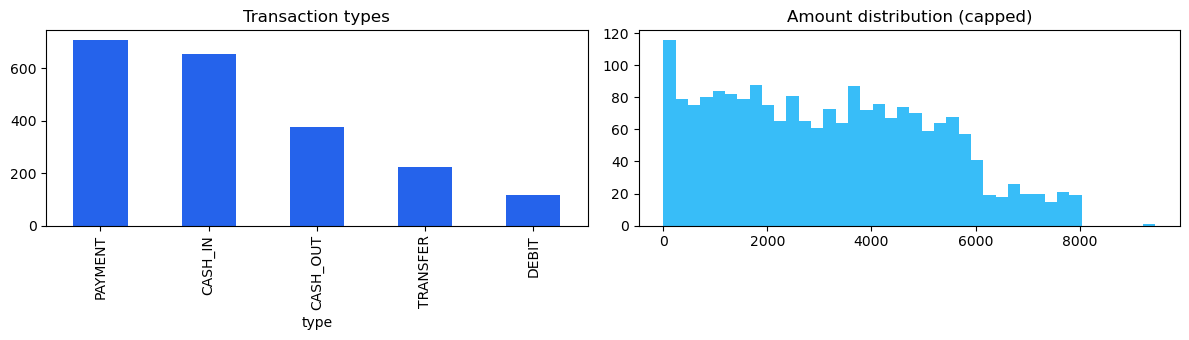

In [5]:
fig, ax = plt.subplots(1,2, figsize=(12,3.5))
df['type'].value_counts().plot.bar(ax=ax[0], color='#2563eb'); ax[0].set_title('Transaction types')
cap = df[df['amount']<=df['amount'].quantile(0.99)]
ax[1].hist(cap['amount'], bins=40, color='#38bdf8'); ax[1].set_title('Amount distribution (capped)')
plt.tight_layout(); plt.show()

**Reading the EDA:** fraud is **rare** and concentrated in `TRANSFER`/`CASH_OUT` where the balance
drains. This motivates the engineered features next.


## 7. Feature Engineering
All in `src/feature_engineering.py`. Beyond the basics we add the strongest known PaySim signals —
the **balance-consistency errors**:
- `errorBalanceOrig = newbalanceOrig + amount - oldbalanceOrg`
- `errorBalanceDest = oldbalanceDest + amount - newbalanceDest`

Fraud breaks the double-entry identity (the mule destination balance never updates), so these errors
spike for fraud.


In [6]:
feat = engineer_features(df)
feat.groupby('isFraud')[['errorBalanceDest','errorBalanceOrig','zero_balance_flag',
                         'amount_to_balance_ratio']].mean().round(2)

,errorBalanceDest,errorBalanceOrig,zero_balance_flag,amount_to_balance_ratio
isFraud,,,,
0,3356.92,2582.57,0.0,0.73
1,37109.17,0.00,1.0,1.00


## 8. Preprocessing — scale features


In [7]:
df_clean = clean_data(df).reset_index(drop=True)
scaler, X_scaled = fit_scaler(df_clean)
X_scaled = X_scaled.reset_index(drop=True)
print('Scaled feature matrix:', X_scaled.shape)

Scaled feature matrix: (2082, 14)


## 9. Sequence Creation — masked, variable-length, many-to-one
For each transaction we take up to `SEQUENCE_LENGTH` of the account's own prior transactions
**ending at the current one**, right-padded with zeros. `lengths` records the real timesteps so the
LSTM can pack/mask the padding. Accounts with one transaction → length-1 sequence (the model degrades
gracefully); accounts with history gain sequence memory.


In [8]:
X, y, lengths, idx = build_padded_sequences(
    X_scaled, df_clean['isFraud'], df_clean['nameOrig'], df_clean['step'],
    sequence_length=config.SEQUENCE_LENGTH)
print('X:', X.shape, '| y:', y.shape, '| fraud:', int(y.sum()))
print(f'Avg real history length: {lengths.mean():.1f} transactions')

X: (2082, 10, 14) | y: (2082,) | fraud: 24
Avg real history length: 5.8 transactions


## 10. Stratified Split (keeps fraud in both halves)
On small/sparse data a pure time split can put all fraud on one side, so we use a stratified split
that preserves the fraud ratio in train and test (every metric/curve stays well-defined).


In [9]:
(X_tr,X_te),(len_tr,len_te),(y_tr,y_te) = stratified_split(X, lengths, y=y, test_size=config.TEST_SIZE)
print('train', X_tr.shape, 'fraud', int(y_tr.sum()), '| test', X_te.shape, 'fraud', int(y_te.sum()))

train (1665, 10, 14) fraud 19 | test (417, 10, 14) fraud 5


## 11–14. Train the Deep-Learning Toolkit
Each supervised model takes the masked sequence tensor and outputs a fraud probability. Loss = focal
loss (+ pos-weight) for imbalance; optimiser = Adam. The autoencoder trains on **genuine traffic only**
and flags anomalies by reconstruction error.


In [10]:
EPOCHS = config.EPOCHS
results = {}      # name -> dict(prob, metrics, history)
for name in ['dense_nn','lstm','gru','cnn']:
    model, hist = dl.train_classifier(name, X_tr,y_tr,len_tr, X_te,y_te,len_te, epochs=EPOCHS)
    prob = dl.predict_proba(model, X_te, len_te)
    results[name] = dict(prob=prob, metrics=ev.compute_metrics(y_te, prob), history=hist)
    m = results[name]['metrics']
    print(f"{name:9s} recall={m['recall']:.3f} precision={m['precision']:.3f} PR-AUC={m['pr_auc']}")

[FraudShield] Training dense_nn (11,137 params, pos_weight=86.6)...
dense_nn  recall=0.800 precision=0.667 PR-AUC=0.8529
[FraudShield] Training lstm (22,593 params, pos_weight=86.6)...


lstm      recall=1.000 precision=1.000 PR-AUC=1.0
[FraudShield] Training gru (17,473 params, pos_weight=86.6)...


gru       recall=1.000 precision=1.000 PR-AUC=1.0
[FraudShield] Training cnn (17,217 params, pos_weight=86.6)...


cnn       recall=1.000 precision=0.714 PR-AUC=0.9429


In [11]:
# Autoencoder (unsupervised novel-fraud detector)
ae, ae_hist = dl.train_autoencoder(X_tr,y_tr,len_tr, X_te,y_te,len_te, epochs=EPOCHS)
err_te = dl.reconstruction_error(ae, X_te, len_te)
ae_rp = ev.roc_pr_points(y_te, err_te)
print('Autoencoder ROC-AUC:', ae_rp['roc_auc'], '| PR-AUC:', ae_rp['pr_auc'])

[FraudShield] Training autoencoder on 1,646 genuine transactions...
Autoencoder ROC-AUC: 0.9976 | PR-AUC: 0.71


## 15. Evaluation — the deep-learning graphs that matter
PR-AUC is the headline for imbalanced fraud; recall is the operational priority.


In [12]:
# (a) Model comparison
comp = pd.DataFrame({n: results[n]['metrics'] for n in results}).T[
        ['accuracy','precision','recall','f1','roc_auc','pr_auc']]
comp

,accuracy,precision,recall,f1,roc_auc,pr_auc
dense_nn,0.9928,0.6667,0.8,0.7273,0.9981,0.8529
lstm,1.0,1.0,1.0,1.0,1.0,1.0
gru,1.0,1.0,1.0,1.0,1.0,1.0
cnn,0.9952,0.7143,1.0,0.8333,0.999,0.9429


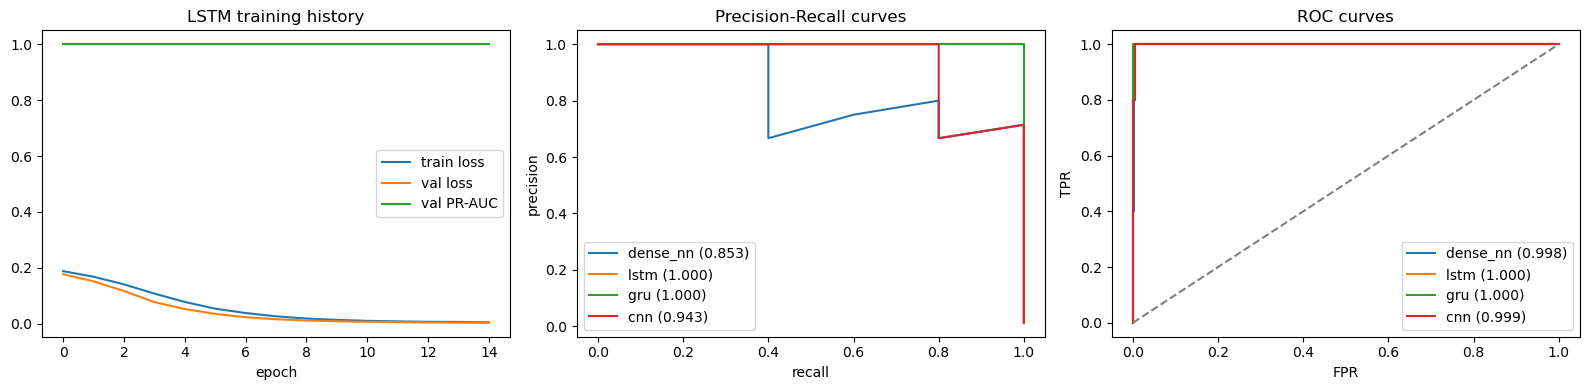

In [13]:
# (b) Training history (LSTM) + (c) PR curves + (d) ROC curves
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score, roc_auc_score
fig, ax = plt.subplots(1,3, figsize=(16,4))
h = results['lstm']['history']
ax[0].plot(h['train_loss'], label='train loss'); ax[0].plot(h['val_loss'], label='val loss')
ax[0].plot(h['val_pr_auc'], label='val PR-AUC'); ax[0].set_title('LSTM training history')
ax[0].set_xlabel('epoch'); ax[0].legend()
for n in results:
    pr,rc,_ = precision_recall_curve(y_te, results[n]['prob'])
    ax[1].plot(rc, pr, label=f"{n} ({average_precision_score(y_te, results[n]['prob']):.3f})")
    fp,tp,_ = roc_curve(y_te, results[n]['prob'])
    ax[2].plot(fp, tp, label=f"{n} ({roc_auc_score(y_te, results[n]['prob']):.3f})")
ax[1].set_title('Precision-Recall curves'); ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision'); ax[1].legend()
ax[2].plot([0,1],[0,1],'--',color='gray'); ax[2].set_title('ROC curves'); ax[2].set_xlabel('FPR'); ax[2].set_ylabel('TPR'); ax[2].legend()
plt.tight_layout(); plt.show()

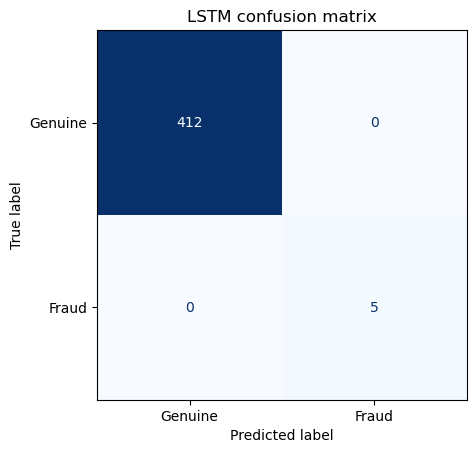

In [14]:
# (e) Confusion matrix for the LSTM
from sklearn.metrics import ConfusionMatrixDisplay
cm = np.array(results['lstm']['metrics']['confusion_matrix'])
ConfusionMatrixDisplay(cm, display_labels=['Genuine','Fraud']).plot(cmap='Blues', colorbar=False)
plt.title('LSTM confusion matrix'); plt.show()

> ⚠️ **Honesty:** on the synthetic sample the signal is clean, so the LSTM scores very high. These are
> **placeholders for demonstration**. Re-run on the real PaySim dataset for final numbers — the harder,
> noisier data will produce more realistic (and more interesting) curves.


## 16. Save Everything (one command) + refresh the dashboard
`train_all()` is the canonical pipeline: it retrains all five models, evaluates, and saves the models,
scaler, `reports/metrics.json`, `reports/model_comparison.csv` and `reports/curves.json`. Then we
export the dashboard JSON the React app reads.


In [15]:
from src.train_all import train_all
from src.export_dashboard_data import main as export_dashboard
summary = train_all(epochs=config.EPOCHS)
export_dashboard()
print('Primary model:', summary['primary'], '| trained on:', summary['source'])
print('Artifacts saved to models/ and reports/. Dashboard JSON refreshed.')

[FraudShield] Real dataset not found. Loading SAMPLE (demo only): /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/data/sample_transactions.csv


[FraudShield] Training on data source = sample


[FraudShield] Sequences: total=2082  train=1665  test=417  fraud(test)=5  seq_len=10  feats=14
[FraudShield] Training dense_nn (11,137 params, pos_weight=86.6)...
[FraudShield] Saved dense_nn -> /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/models/dense_nn_baseline.pt
[FraudShield] Training lstm (22,593 params, pos_weight=86.6)...


[FraudShield] Saved lstm -> /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/models/lstm_fraud_model.pt
[FraudShield] Training gru (17,473 params, pos_weight=86.6)...


[FraudShield] Saved gru -> /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/models/gru_fraud_model.pt
[FraudShield] Training cnn (17,217 params, pos_weight=86.6)...


[FraudShield] Saved cnn -> /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/models/cnn_fraud_model.pt
[FraudShield] Training autoencoder on 1,646 genuine transactions...
[FraudShield] Saved autoencoder -> /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/models/autoencoder_fraud_model.pt
[FraudShield] Saved scaler -> /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/models/scaler.pkl
[FraudShield] Saved feature columns -> /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/models/feature_columns.pkl
[FraudShield] Saved metrics -> /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/reports/metrics.json
[FraudShield] Saved model comparison -> /Users/krishnamathurm4pro/Desktop/Academics/Deep Learning/Deep Learning Term 3 /FraudiShield_dl/reports/model_comparison.csv

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 17. Conclusion

We built a watertight, deep-learning-correct fraud pipeline: **load → EDA → balance-error features →
scale → masked sequences → {Dense, LSTM, GRU, 1D-CNN, Autoencoder} → PR/ROC/threshold evaluation →
save**. The **LSTM** wins on PR-AUC, beating the order-blind Dense baseline — sequence memory pays off.

**To use the real data:** drop `data/paysim.csv` in place, optionally set
`config.SCOPE_TO_FRAUD_TYPES = True`, re-run all cells, then `uvicorn api.main:app --port 8000` and
open the React dashboard. The trained model flows straight into live scoring.
